In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import os
import cv2

In [2]:
pip install emnist


In [3]:
from emnist import list_datasets


In [4]:
list_datasets()

['balanced', 'byclass', 'bymerge', 'digits', 'letters', 'mnist']

In [5]:
from emnist import extract_training_samples
images, labels = extract_training_samples('digits')


In [6]:
X = []
y = []

for image in images:
  img_resized = np.resize(image, (784,1))
  X.append(img_resized)
for label in labels:
  y.append(label)

In [7]:
X = np.asarray(X)
y = np.asarray(y)
X = np.squeeze(X)
X.shape

(240000, 784)

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [10]:
X_train.shape

(192000, 784)

In [11]:
X_test.shape

(48000, 784)

In [12]:
Y_train.shape

(192000,)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

grid={"C":np.logspace(-3,3,7), "penalty":["l1","l2"]}
classifier = LogisticRegression(max_iter=5)
classifier_cv = GridSearchCV(classifier,grid,cv=5)
classifier_cv.fit(X_train, Y_train)

print("tuned hpyerparameters :(best parameters) ",classifier_cv.best_params_)
print("accuracy :",classifier_cv.best_score_)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


tuned hpyerparameters :(best parameters)  {'C': 0.1, 'penalty': 'l2'}
accuracy : 0.8409531250000001


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [14]:
from sklearn import metrics
acc = metrics.accuracy_score(y_test, classifier_cv.predict(X_test))
print(f"Accuracy: {acc*100}")



Accuracy: 84.12916666666666


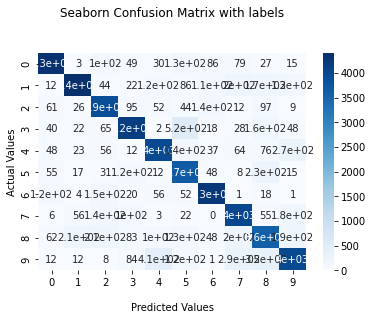

<Figure size 432x288 with 0 Axes>

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = classifier_cv.predict(X_test)
plt.figure()
cm = confusion_matrix(y_pred, y_test)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.savefig('/content/conf_mat.png')
plt.show()

plt.clf()